<a href="https://colab.research.google.com/github/Logic-Voyager/Stock-Price-Prediction-MLP/blob/main/Stock_Price_Prediction_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1978/936600142.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the MLP model...
Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0103 - val_loss: 0.0039
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - val_loss: 0.0025
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - val_loss: 0.0061
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - val_loss: 0.0022
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - val_loss: 7.9093e-04
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - val_loss: 4.9631e-04
Epoch 9/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 7.1238e-04
Epoch 10/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019 - val_loss: 9.7662e-04
Epoch 11/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - val_loss: 7.8383e-04
Epoch 12/50
90/90 ━━━━━━━━━━

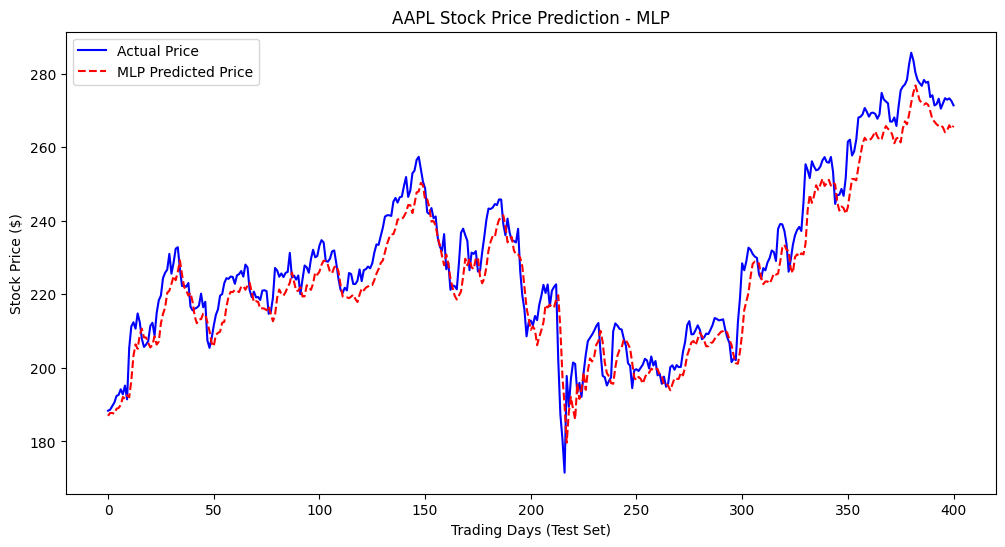

In [1]:
# MLP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Download Historical Stock Data
print("Downloading data...")
ticker = "AAPL"
data = yf.download(ticker, start="2018-01-01", end="2026-01-01")

# Clean data structure and extract Closing prices
df = data[['Close']].dropna()

# 2. Feature Engineering: Create a window of past 10 days to predict the next day
lookback = 10
X, y = [], []
for i in range(len(df) - lookback):
    X.append(df.iloc[i : i + lookback].values)
    y.append(df.iloc[i + lookback].values)

X = np.array(X).reshape(-1, lookback)
y = np.array(y).reshape(-1, 1)

# 3. Data Normalization
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Split into Train and Test sets (80% train, 20% test without shuffling to preserve time order)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

# 4. Build the MLP Architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(lookback,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)  # Linear output for continuous price prediction
])

model.compile(optimizer='adam', loss='mse')

# 5. Train the Model
print("Training the MLP model...")
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# 6. Predict and Inverse Scale
predictions_scaled = model.predict(X_test)
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# 7. Calculate Exact Metrics
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("\n" + "="*30)
print(f"📊 EXACT METRICS FOR YOUR FORM:")
print(f"Dataset Used: Yahoo Finance (Ticker: {ticker})")
print(f"Dataset Size: {len(df)} trading days")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print("="*30)

# 8. Plot the Results
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price", color='blue')
plt.plot(predictions, label="MLP Predicted Price", color='red', linestyle='--')
plt.title(f"{ticker} Stock Price Prediction - MLP")
plt.xlabel("Trading Days (Test Set)")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.savefig("prediction_plot.png")
plt.show()